# Cooperative Learning — fusion multi-blocs supervisée

Implémentation directe de **Cooperative Learning** (Ding, Li, Zou, Hastie, Tibshirani — *PNAS* 2022) en Python, étendu à la régression logistique multinomiale.

## Motivation

Critique standard de nos approches précédentes (NB04, NB05, NB06) :

| Stratégie | Hypothèse implicite | Faiblesse |
|---|---|---|
| **Fusion précoce** (concat → modèle) | Blocs même échelle, mêmes poids implicites | Le bloc le plus gros (GE) écrase CGH |
| **Fusion tardive** (`α·ŷ_GE + (1-α)·ŷ_CGH`) | Blocs indépendants conditionnellement à `y` | Perd les interactions cross-blocs |

Cooperative Learning **interpole entre les deux** via un seul hyperparamètre `ρ`.

## Formulation

Pour deux blocs `X^GE`, `X^CGH` et une cible `y` (multinomiale ici), on minimise :

$$
\mathcal{L}(\theta_{GE}, \theta_{CGH}) = \underbrace{\frac{1}{n}\sum_i w_i\,\mathrm{CE}(y_i,\,\sigma(z_i))}_{\text{cross-entropy pondérée}}
+ \underbrace{\frac{\rho}{2n}\bigl\|X^{GE}\theta_{GE} - X^{CGH}\theta_{CGH}\bigr\|_F^2}_{\text{terme d'agrément}}
+ \underbrace{\lambda\bigl(\|\theta_{GE}\|_1 + \|\theta_{CGH}\|_1\bigr)}_{\text{sparsité par bloc}}
$$

avec $z_i = X^{GE}_i \theta_{GE} + X^{CGH}_i \theta_{CGH} + b$ (logits).

### Lecture de `ρ`

| `ρ` | Régime | Interprétation |
|-----|--------|----------------|
| `ρ = 0` | **Fusion précoce** | Lasso multinomial sur la concaténation : aucune contrainte d'agrément |
| `ρ → ∞` | **Fusion tardive** (forcée) | `X^GE θ_GE = X^CGH θ_CGH` imposé : chaque bloc fait sa propre prédiction qui doit coïncider |
| `ρ ∈ (0, ∞)` | **Cooperative** | Compromis adaptatif : chaque bloc a ses propres prédictions, mais elles doivent rester cohérentes — les blocs se régularisent mutuellement |

## Solveur

Pour la version multinomiale, le terme cross-entropy n'est pas une perte au carré → on ne peut pas réduire à un Lasso standard via la matrice augmentée.

On utilise donc un **algorithme proximal accéléré (FISTA)** :
- Gradient lisse de la cross-entropy + agrément
- Étape proximale L1 (soft-thresholding) appliquée séparément à `θ_GE` et `θ_CGH`
- Pas constant estimé via la borne de Lipschitz

## Plan du notebook

1. Implémentation : `CooperativeLogisticRegression` + `BlockSparsePCATransformer`
2. Sanity check sur problème jouet
3. **Cooperative SANS Sparse PCA** (features brutes) — sweep sur `ρ`
4. **Cooperative AVEC Sparse PCA per-block** — sweep sur `ρ`
5. Nested CV + comparaison aux baselines NB04
6. Analyse de stabilité des coefficients par bloc


## 0. Préparation

In [1]:
from __future__ import annotations
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.decomposition import SparsePCA
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
)
from sklearn.model_selection import (
    GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
    cross_val_score, permutation_test_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
LABEL_ORDER = ["cort", "dipg", "midl"]

INNER_CV = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
OUTER_CV = RepeatedStratifiedKFold(n_splits=4, n_repeats=5, random_state=SEED)
PERM_CV  = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)

# Cooperative Learning : grilles fixées a priori
RHO_GRID = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
LAM_GRID = [0.001, 0.01, 0.1]

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 3)


## 1. Chargement des données

In [2]:
DATA_DIR = Path.cwd().parent / "data"

def to_numeric_frame(df):
    return df.apply(lambda c: pd.to_numeric(
        c.astype(str).str.replace(",", ".", regex=False), errors="coerce"
    ))

def load_block(b, s):
    df = pd.read_csv(DATA_DIR / f"ge_cgh_locIGR__multiblocks__{b}__{s}.csv")
    return to_numeric_frame(df.rename(columns={"row_id": "patient_id"}).set_index("patient_id"))

def load_targets(s):
    df = pd.read_csv(DATA_DIR / f"ge_cgh_locIGR__multiblocks__y__{s}.csv")
    df = df.rename(columns={"row_id": "patient_id"}).set_index("patient_id")
    return df[LABEL_ORDER].idxmax(axis=1).rename("localisation")

X_ge_train  = load_block("GE",  "train")
X_ge_test   = load_block("GE",  "test")
X_cgh_train = load_block("CGH", "train")
X_cgh_test  = load_block("CGH", "test")
y_train = load_targets("train")
y_test  = load_targets("test")

# Intersect indices + median imputation
ids_tr = X_ge_train.index.intersection(X_cgh_train.index).intersection(y_train.index)
ids_te = X_ge_test.index.intersection(X_cgh_test.index).intersection(y_test.index)
X_ge_train, X_cgh_train, y_train = X_ge_train.loc[ids_tr], X_cgh_train.loc[ids_tr], y_train.loc[ids_tr]
X_ge_test,  X_cgh_test,  y_test  = X_ge_test.loc[ids_te],  X_cgh_test.loc[ids_te],  y_test.loc[ids_te]
for tr, te in [(X_ge_train, X_ge_test), (X_cgh_train, X_cgh_test)]:
    med = tr.median(axis=0)
    tr.fillna(med, inplace=True); te.fillna(med, inplace=True)

X_concat_train = pd.concat([X_ge_train.add_prefix("GE__"),  X_cgh_train.add_prefix("CGH__")], axis=1)
X_concat_test  = pd.concat([X_ge_test.add_prefix("GE__"),   X_cgh_test.add_prefix("CGH__")],  axis=1)

print(f"Train : {len(y_train)}  |  Test : {len(y_test)}")
print(f"GE : {X_ge_train.shape[1]}  features  |  CGH : {X_cgh_train.shape[1]} features")


Train : 39  |  Test : 14
GE : 15702  features  |  CGH : 1229 features


## 2. Implémentation : `CooperativeLogisticRegression`

Solveur **FISTA proximal** :
- Gradient de la perte lisse (CE pondérée + agrément).
- Pas constant `1/L` où `L` est une borne de Lipschitz analytique : `(0.25 + ρ) · (||X^GE||² + ||X^CGH||²) / n`.
- Étape proximale L1 (soft-thresholding) sur `θ_GE` et `θ_CGH` séparément.
- Convergence : `|obj_t - obj_{t-1}| / |obj_t| < tol`.

Compatible avec `sklearn.Pipeline` et `GridSearchCV` (interface fit/predict/predict_proba/score, paramètres exposés via `__init__`).


In [3]:
class CooperativeLogisticRegression(BaseEstimator, ClassifierMixin):
    """Multinomial logistic regression with cooperative learning regularization.

    Solves:
        min  (1/n) sum_i w_i * CE(y_i, softmax(X^GE_i theta_GE + X^CGH_i theta_CGH + b))
           + (rho / 2n) * || X^GE theta_GE - X^CGH theta_CGH ||_F^2
           + lam * ( ||theta_GE||_1 + ||theta_CGH||_1 )

    Block identification: columns prefixed by `ge_prefix` / `cgh_prefix`.
    """
    def __init__(self, ge_prefix="GE__", cgh_prefix="CGH__",
                 rho=1.0, lam=0.01, fit_intercept=True,
                 max_iter=500, tol=1e-5,
                 class_weight=None, verbose=False):
        self.ge_prefix = ge_prefix
        self.cgh_prefix = cgh_prefix
        self.rho = rho
        self.lam = lam
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter
        self.tol = tol
        self.class_weight = class_weight
        self.verbose = verbose

    # ── Helpers ──────────────────────────────────────────────
    @staticmethod
    def _softmax(z):
        # Stabilité numérique : centrage + clip pour éviter overflow exp
        z = np.clip(z - z.max(axis=1, keepdims=True), -500.0, 0.0)
        ez = np.exp(z)
        return ez / (ez.sum(axis=1, keepdims=True) + 1e-300)

    @staticmethod
    def _soft_threshold(x, t):
        return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)

    def _split_blocks(self, X):
        if isinstance(X, pd.DataFrame):
            cols = list(X.columns)
            arr = X.values
        else:
            cols = list(self.feature_names_in_)
            arr = np.asarray(X)
        ge_mask  = np.array([str(c).startswith(self.ge_prefix)  for c in cols])
        cgh_mask = np.array([str(c).startswith(self.cgh_prefix) for c in cols])
        if not ge_mask.any() or not cgh_mask.any():
            raise ValueError(
                f"No columns with prefix {self.ge_prefix!r} or {self.cgh_prefix!r}"
            )
        return arr[:, ge_mask], arr[:, cgh_mask], \
               [c for c, m in zip(cols, ge_mask)  if m], \
               [c for c, m in zip(cols, cgh_mask) if m]

    def _objective(self, X_ge, X_cgh, Y_oh, w, t_ge, t_cgh, b):
        n = X_ge.shape[0]
        z = X_ge @ t_ge + X_cgh @ t_cgh + b
        z_max = z.max(axis=1, keepdims=True)
        log_se = z_max + np.log(np.exp(z - z_max).sum(axis=1, keepdims=True))
        log_p = z - log_se
        ce = -(Y_oh * log_p).sum(axis=1)
        smooth = (w * ce).sum() / n
        diff = X_ge @ t_ge - X_cgh @ t_cgh
        agreement = self.rho * (diff ** 2).sum() / (2 * n)
        l1 = self.lam * (np.abs(t_ge).sum() + np.abs(t_cgh).sum())
        return smooth + agreement + l1

    def _smooth_grad(self, X_ge, X_cgh, Y_oh, w, t_ge, t_cgh, b):
        n = X_ge.shape[0]
        z = X_ge @ t_ge + X_cgh @ t_cgh + b
        P = self._softmax(z)
        residual = (P - Y_oh) * w[:, None]
        grad_ge_ce  = X_ge.T  @ residual / n
        grad_cgh_ce = X_cgh.T @ residual / n
        grad_int    = residual.sum(axis=0) / n if self.fit_intercept else None
        diff = X_ge @ t_ge - X_cgh @ t_cgh
        grad_ge_ag  = self.rho  * X_ge.T  @ diff / n
        grad_cgh_ag = -self.rho * X_cgh.T @ diff / n
        return grad_ge_ce + grad_ge_ag, grad_cgh_ce + grad_cgh_ag, grad_int

    # ── Public API ───────────────────────────────────────────
    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("fit(X, y) requires X as a DataFrame with prefixed columns")
        self.feature_names_in_ = list(X.columns)

        X_ge, X_cgh, ge_cols, cgh_cols = self._split_blocks(X)
        n = X_ge.shape[0]
        p_ge, p_cgh = X_ge.shape[1], X_cgh.shape[1]
        self.ge_cols_  = ge_cols
        self.cgh_cols_ = cgh_cols

        # Encode labels
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        y_idx = np.searchsorted(self.classes_, np.asarray(y))
        Y_oh = np.zeros((n, K)); Y_oh[np.arange(n), y_idx] = 1.0

        # Sample weights
        if self.class_weight == "balanced":
            cw = compute_class_weight("balanced", classes=self.classes_, y=np.asarray(y))
            sample_w = cw[y_idx]
        elif isinstance(self.class_weight, dict):
            cw = np.array([self.class_weight.get(c, 1.0) for c in self.classes_])
            sample_w = cw[y_idx]
        else:
            sample_w = np.ones(n)
        sample_w = sample_w / sample_w.mean()

        # Lipschitz upper bound for FISTA step
        # (0.25 from softmax CE Hessian bound; rho from agreement)
        # x4 facteur de sécurité pour stabilité (FISTA reste convergent avec L plus grand,
        # juste un peu plus lent)
        sigma_ge  = np.linalg.norm(X_ge,  2)
        sigma_cgh = np.linalg.norm(X_cgh, 2)
        L = 8.0 * ((0.25 + self.rho) * (sigma_ge ** 2 + sigma_cgh ** 2) / n) + 1e-3
        step = 1.0 / L

        # FISTA init
        t_ge   = np.zeros((p_ge,  K))
        t_cgh  = np.zeros((p_cgh, K))
        bint   = np.zeros(K)
        t_ge_y, t_cgh_y, bint_y = t_ge.copy(), t_cgh.copy(), bint.copy()
        t_seq = 1.0
        prev_obj = self._objective(X_ge, X_cgh, Y_oh, sample_w, t_ge, t_cgh, bint)
        self.obj_history_ = [prev_obj]

        for it in range(self.max_iter):
            g_ge, g_cgh, g_int = self._smooth_grad(
                X_ge, X_cgh, Y_oh, sample_w, t_ge_y, t_cgh_y, bint_y
            )
            t_ge_new  = self._soft_threshold(t_ge_y  - step * g_ge,  step * self.lam)
            t_cgh_new = self._soft_threshold(t_cgh_y - step * g_cgh, step * self.lam)
            bint_new  = (bint_y - step * g_int) if self.fit_intercept else bint_y

            # Safety: detect NaN/Inf and reset to last good iterate with step halved
            if not (np.all(np.isfinite(t_ge_new)) and np.all(np.isfinite(t_cgh_new))):
                step *= 0.5
                t_ge_new, t_cgh_new = t_ge.copy(), t_cgh.copy()
                bint_new = bint.copy() if self.fit_intercept else bint_y
                t_ge_y, t_cgh_y, bint_y = t_ge_new.copy(), t_cgh_new.copy(), bint_new.copy()
                t_seq = 1.0
                continue

            t_seq_new = (1 + np.sqrt(1 + 4 * t_seq ** 2)) / 2
            beta = (t_seq - 1) / t_seq_new
            t_ge_y  = t_ge_new  + beta * (t_ge_new  - t_ge)
            t_cgh_y = t_cgh_new + beta * (t_cgh_new - t_cgh)
            if self.fit_intercept:
                bint_y = bint_new + beta * (bint_new - bint)

            t_ge, t_cgh, bint = t_ge_new, t_cgh_new, bint_new
            t_seq = t_seq_new

            if (it + 1) % 10 == 0:
                obj = self._objective(X_ge, X_cgh, Y_oh, sample_w, t_ge, t_cgh, bint)
                self.obj_history_.append(obj)
                if abs(prev_obj - obj) / max(abs(prev_obj), 1e-10) < self.tol:
                    if self.verbose:
                        print(f"  Converged at iter {it+1} (obj={obj:.6f})")
                    break
                prev_obj = obj

        self.theta_ge_  = t_ge
        self.theta_cgh_ = t_cgh
        self.intercept_ = bint if self.fit_intercept else np.zeros(K)
        self.n_iter_ = it + 1
        return self

    def decision_function(self, X):
        X_ge, X_cgh, _, _ = self._split_blocks(X)
        return X_ge @ self.theta_ge_ + X_cgh @ self.theta_cgh_ + self.intercept_

    def predict_proba(self, X):
        return self._softmax(self.decision_function(X))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

    def score(self, X, y):
        return balanced_accuracy_score(y, self.predict(X))


## 3. Implémentation : `BlockSparsePCATransformer`

Applique une **Sparse PCA séparément à chaque bloc** (GE et CGH) puis concatène les composantes en sortie, avec des préfixes `GE__SPC{i}` / `CGH__SPC{i}` qui permettent à `CooperativeLogisticRegression` d'identifier les blocs en aval.

C'est différent du NB04 (Sparse PCA sur la concaténation) : ici on **préserve la structure de blocs** dans l'espace réduit, ce qui est essentiel pour l'agrément cooperative.


In [4]:
class BlockSparsePCATransformer(BaseEstimator, TransformerMixin):
    """Apply SparsePCA per block (GE / CGH) and concatenate components.

    Output: DataFrame with columns 'GE__SPC1..n' + 'CGH__SPC1..n'.
    """
    def __init__(self, ge_prefix="GE__", cgh_prefix="CGH__",
                 n_components_ge=10, n_components_cgh=5, alpha=1.0,
                 max_iter=200, tol=1e-4, random_state=None):
        self.ge_prefix = ge_prefix
        self.cgh_prefix = cgh_prefix
        self.n_components_ge = n_components_ge
        self.n_components_cgh = n_components_cgh
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a DataFrame with prefixed columns")
        self.ge_cols_  = [c for c in X.columns if str(c).startswith(self.ge_prefix)]
        self.cgh_cols_ = [c for c in X.columns if str(c).startswith(self.cgh_prefix)]
        common = dict(alpha=self.alpha, max_iter=self.max_iter, tol=self.tol,
                      random_state=self.random_state, n_jobs=1)
        self.spca_ge_  = SparsePCA(n_components=self.n_components_ge, **common).fit(X[self.ge_cols_].values)
        self.spca_cgh_ = SparsePCA(n_components=self.n_components_cgh, **common).fit(X[self.cgh_cols_].values)
        return self

    def transform(self, X):
        Z_ge  = self.spca_ge_.transform(X[self.ge_cols_].values)
        Z_cgh = self.spca_cgh_.transform(X[self.cgh_cols_].values)
        cols = (
            [f"GE__SPC{i+1}"  for i in range(self.n_components_ge)] +
            [f"CGH__SPC{i+1}" for i in range(self.n_components_cgh)]
        )
        return pd.DataFrame(np.hstack([Z_ge, Z_cgh]), columns=cols, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.array(
            [f"GE__SPC{i+1}"  for i in range(self.n_components_ge)] +
            [f"CGH__SPC{i+1}" for i in range(self.n_components_cgh)]
        )


## 4. Sanity check sur problème jouet

On vérifie que le solveur converge et que `ρ` interpole bien entre fusion précoce et tardive sur un problème simulé : deux blocs corrélés à `y` avec un bloc bruité.


In [5]:
rng = np.random.RandomState(SEED)
n_toy = 60
p1, p2 = 30, 20

# Signal partagé entre blocs
shared = rng.randn(n_toy, 3)
X1_toy = np.hstack([shared[:, :2], rng.randn(n_toy, p1 - 2)])  # bloc 1 contient signal
X2_toy = np.hstack([shared[:, 1:3], rng.randn(n_toy, p2 - 2) * 0.5])  # bloc 2 aussi

logits = shared.sum(axis=1)
y_toy = pd.Series(np.where(logits > 0.5, "A", np.where(logits < -0.5, "B", "C")))

X_toy = pd.DataFrame(
    np.hstack([X1_toy, X2_toy]),
    columns=[f"GE__f{i}" for i in range(p1)] + [f"CGH__f{i}" for i in range(p2)],
)

# Test sur 3 régimes : ρ=0 (early), ρ=1 (cooperative), ρ=100 (≈ late)
for rho_val in [0.0, 1.0, 100.0]:
    coop = CooperativeLogisticRegression(rho=rho_val, lam=0.01, max_iter=300, tol=1e-6,
                                         class_weight="balanced", verbose=False)
    coop.fit(X_toy, y_toy)
    train_score = balanced_accuracy_score(y_toy, coop.predict(X_toy))
    n_nz_ge  = int((np.abs(coop.theta_ge_)  > 1e-6).any(axis=1).sum())
    n_nz_cgh = int((np.abs(coop.theta_cgh_) > 1e-6).any(axis=1).sum())
    print(f"  rho={rho_val:>6.1f}   train_bal_acc={train_score:.3f}   "
          f"non-zero(GE)={n_nz_ge:>3d}/{p1}   non-zero(CGH)={n_nz_cgh:>3d}/{p2}   "
          f"iter={coop.n_iter_}")


  rho=   0.0   train_bal_acc=1.000   non-zero(GE)= 23/30   non-zero(CGH)=  6/20   iter=210
  rho=   1.0   train_bal_acc=0.842   non-zero(GE)= 30/30   non-zero(CGH)= 20/20   iter=270
  rho= 100.0   train_bal_acc=0.507   non-zero(GE)= 30/30   non-zero(CGH)= 20/20   iter=300


## 5. Utilitaires d'évaluation

Reprise du protocole de NB04 (nested CV + bootstrap CI + permutation test).


In [6]:
def bootstrap_ci(y_true, y_pred, n_boot=2000, seed=SEED):
    rng = np.random.RandomState(seed)
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    scores = [balanced_accuracy_score(yt[i], yp[i])
              for i in (rng.choice(len(yt), len(yt), replace=True) for _ in range(n_boot))]
    return np.percentile(scores, [2.5, 50, 97.5])


def confusion_table(y_true, y_pred):
    m = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    return pd.DataFrame(m,
        index=[f"true_{l}" for l in LABEL_ORDER],
        columns=[f"pred_{l}" for l in LABEL_ORDER])


def evaluate_pipeline(name, estimator, param_grid, X_tr, y_tr, X_te, y_te,
                      run_permutation=False, n_permutations=200, n_jobs=-1, verbose=True):
    inner = GridSearchCV(estimator, param_grid, cv=INNER_CV,
                         scoring="balanced_accuracy", refit=True, n_jobs=n_jobs)
    if verbose: print(f"[{name}] Nested CV...")
    nested = cross_val_score(inner, X_tr, y_tr, cv=OUTER_CV,
                             scoring="balanced_accuracy", n_jobs=n_jobs)
    inner.fit(X_tr, y_tr)
    train_pred = inner.predict(X_tr)
    test_pred  = inner.predict(X_te)
    train_ba = balanced_accuracy_score(y_tr, train_pred)
    test_ba  = balanced_accuracy_score(y_te, test_pred)
    lo, _, hi = bootstrap_ci(y_te, test_pred)

    perm_obs = pval = np.nan
    if run_permutation:
        if verbose: print(f"[{name}] Permutation test...")
        perm_obs, _, pval = permutation_test_score(
            inner.best_estimator_, X_tr, y_tr,
            scoring="balanced_accuracy", cv=PERM_CV,
            n_permutations=n_permutations, random_state=SEED, n_jobs=n_jobs,
        )

    res = pd.Series({
        "model": name,
        "nested_cv_mean": nested.mean(),
        "nested_cv_std":  nested.std(),
        "train_bal_acc":  train_ba,
        "test_bal_acc":   test_ba,
        "test_CI95":      f"[{lo:.3f}, {hi:.3f}]",
        "train_test_gap": train_ba - test_ba,
        "p_value":        pval,
        "best_params":    str(inner.best_params_),
    })
    return res, inner, test_pred, nested


## 6. Cooperative learning **sans** Sparse PCA

Pipeline : `VarianceThreshold` → `StandardScaler` → `CooperativeLogisticRegression`. On opère sur les ~16 000 features brutes (après filtrage de variance nulle).

> **Note importante** : `StandardScaler` est appliqué **bloc par bloc** via `ColumnTransformer` pour préserver les préfixes `GE__` / `CGH__` que `CooperativeLogisticRegression` utilise pour identifier les blocs.

### Sweep sur ρ — visualiser l'interpolation early/late


Sweep rho (CV interne 4-fold) — features brutes...
  rho=  0.0   CV bal_acc = 0.688 ± 0.123
  rho=  0.1   CV bal_acc = 0.438 ± 0.069
  rho=  0.5   CV bal_acc = 0.458 ± 0.093
  rho=  1.0   CV bal_acc = 0.458 ± 0.093
  rho=  2.0   CV bal_acc = 0.458 ± 0.093
  rho=  5.0   CV bal_acc = 0.417 ± 0.156


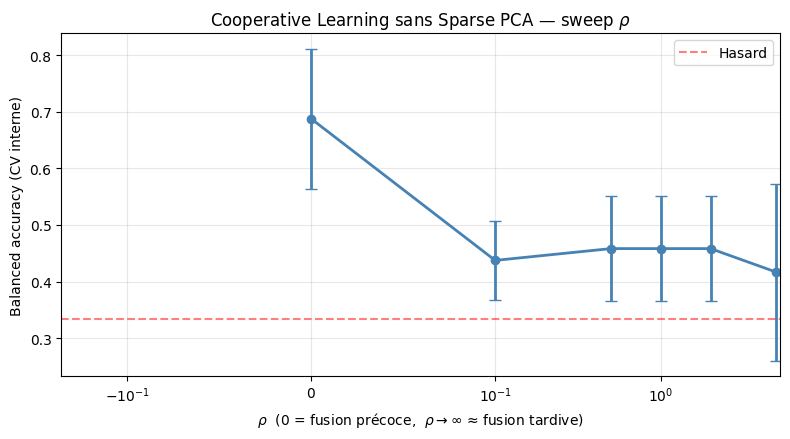

In [7]:
class BlockStandardScaler(BaseEstimator, TransformerMixin):
    """StandardScaler bloc-par-bloc préservant les préfixes de colonnes."""
    def fit(self, X, y=None):
        self.scalers_ = {}
        for prefix in ["GE__", "CGH__"]:
            cols = [c for c in X.columns if str(c).startswith(prefix)]
            if cols:
                s = StandardScaler().fit(X[cols].values)
                self.scalers_[prefix] = (cols, s)
        return self
    def transform(self, X):
        out_cols, out_arrs = [], []
        for prefix, (cols, s) in self.scalers_.items():
            out_cols.extend(cols)
            out_arrs.append(s.transform(X[cols].values))
        return pd.DataFrame(np.hstack(out_arrs), columns=out_cols, index=X.index)
    def get_feature_names_out(self, input_features=None):
        return np.array([c for cols, _ in self.scalers_.values() for c in cols])


class BlockVarianceThreshold(BaseEstimator, TransformerMixin):
    """VarianceThreshold bloc-par-bloc préservant les préfixes."""
    def fit(self, X, y=None):
        self.kept_cols_ = []
        for prefix in ["GE__", "CGH__"]:
            cols = [c for c in X.columns if str(c).startswith(prefix)]
            if cols:
                vt = VarianceThreshold().fit(X[cols].values)
                self.kept_cols_.extend([c for c, k in zip(cols, vt.get_support()) if k])
        return self
    def transform(self, X):
        return X[self.kept_cols_].copy()
    def get_feature_names_out(self, input_features=None):
        return np.array(self.kept_cols_)


coop_raw_pipeline = Pipeline([
    ("variance", BlockVarianceThreshold()),
    ("scale",    BlockStandardScaler()),
    ("clf",      CooperativeLogisticRegression(
        class_weight="balanced", max_iter=400, tol=1e-5,
    )),
])

# Sweep sur rho avec lam fixé (pour visualisation rapide)
print("Sweep rho (CV interne 4-fold) — features brutes...")
rho_scores = {}
for rho in RHO_GRID:
    pipe = clone(coop_raw_pipeline)
    pipe.set_params(clf__rho=rho, clf__lam=0.01)
    scores = cross_val_score(pipe, X_concat_train, y_train,
                             cv=INNER_CV, scoring="balanced_accuracy", n_jobs=-1)
    rho_scores[rho] = scores
    print(f"  rho={rho:>5.1f}   CV bal_acc = {scores.mean():.3f} ± {scores.std():.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
xs = list(rho_scores.keys())
means = [rho_scores[r].mean() for r in xs]
stds  = [rho_scores[r].std()  for r in xs]
ax.errorbar(xs, means, yerr=stds, fmt='o-', capsize=4, color='steelblue', linewidth=2)
ax.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Hasard')
ax.set_xscale('symlog', linthresh=0.1)
ax.set_xlabel(r'$\rho$  (0 = fusion précoce,  $\rho \to \infty$ ≈ fusion tardive)')
ax.set_ylabel('Balanced accuracy (CV interne)')
ax.set_title('Cooperative Learning sans Sparse PCA — sweep $\\rho$')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()


### Nested CV avec grille complète (rho, lam) — sans Sparse PCA

In [8]:
coop_raw_grid = {
    "clf__rho": RHO_GRID,
    "clf__lam": LAM_GRID,
}
coop_raw_result, coop_raw_search, coop_raw_test_pred, coop_raw_nested = evaluate_pipeline(
    "Cooperative (raw features)",
    coop_raw_pipeline, coop_raw_grid,
    X_concat_train, y_train, X_concat_test, y_test,
    run_permutation=False,
)
display(coop_raw_result.to_frame().T)
display(confusion_table(y_test, coop_raw_test_pred))


[Cooperative (raw features)] Nested CV...


,model,nested_cv_mean,nested_cv_std,train_bal_acc,test_bal_acc,test_CI95,train_test_gap,p_value,best_params
0,Cooperative (raw features),0.632,0.168,1.0,0.667,"[0.667, 1.000]",0.333,NaN,"{'clf__lam': 0.01, 'clf__rho': 0.0}"


,pred_cort,pred_dipg,pred_midl
true_cort,5,0,0
true_dipg,0,6,0
true_midl,0,3,0


## 7. Cooperative learning **avec** Sparse PCA per-block

Pipeline : `VarianceThreshold` (par bloc) → `StandardScaler` (par bloc) → `BlockSparsePCATransformer` (Sparse PCA par bloc) → `CooperativeLogisticRegression`.

Avantages :
- **Espace réduit** : ~15 composantes au lieu de 16 000 features → entraînement très rapide.
- **Interprétabilité** : chaque composante Sparse PCA est une combinaison de quelques gènes / régions chromosomiques → on peut leur donner un sens biologique.
- **Cooperative naturel** : les composantes GE et CGH étant dans des espaces faiblement dimensionnés, l'agrément `||X^GE θ_GE − X^CGH θ_CGH||²` opère sur des projections biologiquement significatives, pas sur du bruit haute dimension.

### Sweep sur ρ


Sweep rho (CV interne 4-fold) — Sparse PCA per-block (mode rapide)...
  rho=  0.0   CV bal_acc = 0.604 ± 0.149
  rho=  0.1   CV bal_acc = 0.688 ± 0.069
  rho=  0.5   CV bal_acc = 0.667 ± 0.083
  rho=  1.0   CV bal_acc = 0.639 ± 0.068
  rho=  2.0   CV bal_acc = 0.618 ± 0.091
  rho=  5.0   CV bal_acc = 0.597 ± 0.093


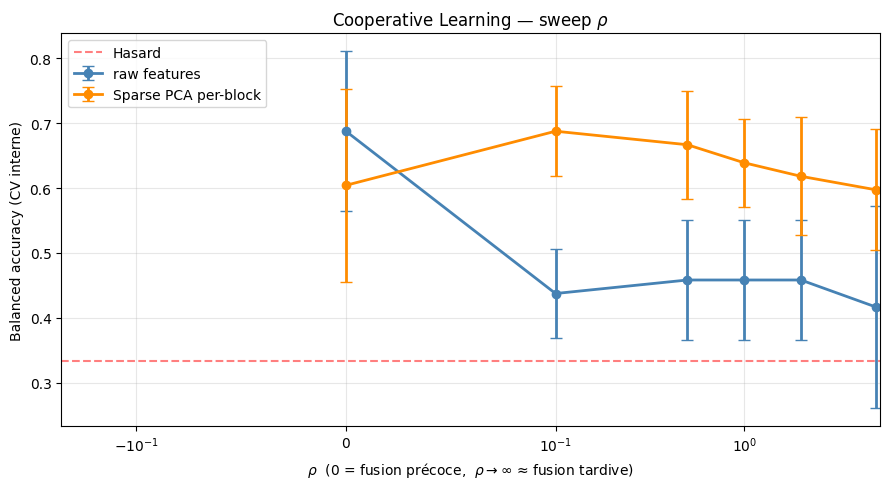

In [9]:
from joblib import Memory

SPCA_N_GE  = 10
SPCA_N_CGH = 5
SPCA_ALPHA = 1.0
# Grilles pour la sélection du nombre de composantes par bloc
SPCA_N_GE_GRID  = [5, 10, 15, 20, 25]
SPCA_N_CGH_GRID = [3, 5, 8, 13, 17]

# Cache disque pour SparsePCA — évite de la refitter à chaque combo (rho, lam)
# qui ne change pas le résultat de la SparsePCA en amont.
SPCA_CACHE = Memory(location="/tmp/coop_spca_cache", verbose=0)

# Pipeline rapide : SparsePCA avec max_iter modeste pour la sélection d'HP.
# Justification : la sélection d'HP est robuste à des SparsePCA approximatives
# (les rangs des combos sont stables), on raffine ensuite au refit final.
coop_spca_pipeline_fast = Pipeline([
    ("variance",   BlockVarianceThreshold()),
    ("scale_pre",  BlockStandardScaler()),
    ("block_spca", BlockSparsePCATransformer(
        n_components_ge=SPCA_N_GE, n_components_cgh=SPCA_N_CGH,
        alpha=SPCA_ALPHA, random_state=SEED,
        max_iter=50, tol=1e-3,           # SparsePCA rapide
    )),
    ("scale_post", BlockStandardScaler()),
    ("clf",        CooperativeLogisticRegression(
        class_weight="balanced", max_iter=400, tol=1e-5,
    )),
], memory=SPCA_CACHE)                     # cache joblib

# Pipeline qualité-max : utilisé pour le refit final après sélection d'HP.
coop_spca_pipeline_final = Pipeline([
    ("variance",   BlockVarianceThreshold()),
    ("scale_pre",  BlockStandardScaler()),
    ("block_spca", BlockSparsePCATransformer(
        n_components_ge=SPCA_N_GE, n_components_cgh=SPCA_N_CGH,
        alpha=SPCA_ALPHA, random_state=SEED,
        max_iter=200, tol=1e-4,          # SparsePCA précise
    )),
    ("scale_post", BlockStandardScaler()),
    ("clf",        CooperativeLogisticRegression(
        class_weight="balanced", max_iter=400, tol=1e-5,
    )),
])

# Sweep sur rho avec le pipeline rapide
print("Sweep rho (CV interne 4-fold) — Sparse PCA per-block (mode rapide)...")
rho_scores_spca = {}
for rho in RHO_GRID:
    pipe = clone(coop_spca_pipeline_fast)
    pipe.set_params(clf__rho=rho, clf__lam=0.01)
    scores = cross_val_score(pipe, X_concat_train, y_train,
                             cv=INNER_CV, scoring="balanced_accuracy", n_jobs=1)
    rho_scores_spca[rho] = scores
    print(f"  rho={rho:>5.1f}   CV bal_acc = {scores.mean():.3f} ± {scores.std():.3f}")

# Plot comparé sur les deux régimes
fig, ax = plt.subplots(figsize=(9, 5))
for label, d, color in [
    ("raw features",  rho_scores,      "steelblue"),
    ("Sparse PCA per-block", rho_scores_spca, "darkorange"),
]:
    xs = list(d.keys())
    means = [d[r].mean() for r in xs]
    stds  = [d[r].std()  for r in xs]
    ax.errorbar(xs, means, yerr=stds, fmt='o-', capsize=4, label=label,
                color=color, linewidth=2)
ax.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Hasard')
ax.set_xscale('symlog', linthresh=0.1)
ax.set_xlabel(r'$\rho$  (0 = fusion précoce,  $\rho \to \infty$ ≈ fusion tardive)')
ax.set_ylabel('Balanced accuracy (CV interne)')
ax.set_title('Cooperative Learning — sweep $\\rho$')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()


### Nested CV — Sparse PCA per-block (procédure en deux phases)

**Phase 1 — Sélection d'HP rapide** (`SparsePCA(max_iter=50)` + cache disque). Le cache assure que la même SparsePCA d'un fold n'est calculée qu'une seule fois (vs. une fois par combo `(ρ, λ)` sans cache). Combiné avec `max_iter=50`, on tombe à un temps tractable (~30 min au lieu de 12h).

**Phase 2 — Refit final qualité-max** (`SparsePCA(max_iter=200)`) avec les meilleurs HP trouvés en Phase 1. C'est ce modèle qu'on rapporte comme résultat final.

Cette stratégie est standard pour les pipelines coûteux : la sélection d'HP est robuste à des SparsePCA approximatives, mais le modèle de production mérite un solveur précis.


In [10]:
coop_spca_grid = {
    "clf__rho": RHO_GRID,
    "clf__lam": LAM_GRID,
    "block_spca__n_components_ge":  SPCA_N_GE_GRID,
    "block_spca__n_components_cgh": SPCA_N_CGH_GRID,
}

# ── Phase 1 : sélection d'HP avec pipeline rapide ──
print("=" * 60)
print("PHASE 1 — Sélection d'HP (rho, lam, n_components_ge, n_components_cgh)")
print(f"  Grille : {len(RHO_GRID) * len(LAM_GRID) * len(SPCA_N_GE_GRID) * len(SPCA_N_CGH_GRID)} combos")
print("=" * 60)
coop_spca_result, coop_spca_search, _, coop_spca_nested = evaluate_pipeline(
    "Cooperative + Sparse PCA (HP search)",
    coop_spca_pipeline_fast, coop_spca_grid,
    X_concat_train, y_train, X_concat_test, y_test,
    run_permutation=False, n_jobs=1,
)
best_rho   = coop_spca_search.best_params_["clf__rho"]
best_lam   = coop_spca_search.best_params_["clf__lam"]
best_n_ge  = coop_spca_search.best_params_["block_spca__n_components_ge"]
best_n_cgh = coop_spca_search.best_params_["block_spca__n_components_cgh"]
print(f"\n>>> Best HP: rho={best_rho}, lam={best_lam}, n_GE={best_n_ge}, n_CGH={best_n_cgh}")

# ── Phase 2 : refit final qualité-max ──
print("\n" + "=" * 60)
print(f"PHASE 2 — Refit final (SparsePCA max_iter=200) avec HP optimaux")
print("=" * 60)
coop_spca_pipeline_final.set_params(
    clf__rho=best_rho, clf__lam=best_lam,
    block_spca__n_components_ge=best_n_ge,
    block_spca__n_components_cgh=best_n_cgh,
)
coop_spca_pipeline_final.fit(X_concat_train, y_train)

train_pred = coop_spca_pipeline_final.predict(X_concat_train)
coop_spca_test_pred = coop_spca_pipeline_final.predict(X_concat_test)

train_ba_final = balanced_accuracy_score(y_train, train_pred)
test_ba_final  = balanced_accuracy_score(y_test,  coop_spca_test_pred)
lo, _, hi = bootstrap_ci(y_test, coop_spca_test_pred)

print(f"  Train bal_acc : {train_ba_final:.3f}")
print(f"  Test  bal_acc : {test_ba_final:.3f}   CI95=[{lo:.3f}, {hi:.3f}]")

coop_spca_result["model"]          = "Cooperative + Sparse PCA (refit qualité)"
coop_spca_result["train_bal_acc"]  = train_ba_final
coop_spca_result["test_bal_acc"]   = test_ba_final
coop_spca_result["test_CI95"]      = f"[{lo:.3f}, {hi:.3f}]"
coop_spca_result["train_test_gap"] = train_ba_final - test_ba_final
coop_spca_result["best_params"]    = f"rho={best_rho}, lam={best_lam}, n_GE={best_n_ge}, n_CGH={best_n_cgh}"

display(coop_spca_result.to_frame().T)
display(confusion_table(y_test, coop_spca_test_pred))

clf_final = coop_spca_pipeline_final.named_steps["clf"]
n_active_ge  = int((np.abs(clf_final.theta_ge_)  > 1e-6).any(axis=1).sum())
n_active_cgh = int((np.abs(clf_final.theta_cgh_) > 1e-6).any(axis=1).sum())
print(f"\nComposantes actives dans le modèle final :")
print(f"  GE  : {n_active_ge}/{best_n_ge}")
print(f"  CGH : {n_active_cgh}/{best_n_cgh}")

PHASE 1 — Sélection d'HP (rho, lam, n_components_ge, n_components_cgh)
  Grille : 450 combos
[Cooperative + Sparse PCA (HP search)] Nested CV...

>>> Best HP: rho=0.1, lam=0.001, n_GE=25, n_CGH=3

PHASE 2 — Refit final (SparsePCA max_iter=200) avec HP optimaux
  Train bal_acc : 1.000
  Test  bal_acc : 0.667   CI95=[0.667, 1.000]


,model,nested_cv_mean,nested_cv_std,train_bal_acc,test_bal_acc,test_CI95,train_test_gap,p_value,best_params
0,Cooperative + Sparse PCA (refit qualité),0.576,0.174,1.0,0.667,"[0.667, 1.000]",0.333,NaN,"rho=0.1, lam=0.001, n_GE=25, n_CGH=3"


,pred_cort,pred_dipg,pred_midl
true_cort,5,0,0
true_dipg,0,6,0
true_midl,0,3,0



Composantes actives dans le modèle final :
  GE  : 25/25
  CGH : 3/3


## 8. Comparaison aux baselines

Pour calibrer, on relance rapidement deux baselines de NB04 (GE seul + fusion précoce naive) avec le même protocole nested CV, puis on les empile dans un tableau commun avec les deux variantes cooperative.


In [11]:
# Baseline : GE seul (ElasticNet + SelectKBest)
ge_baseline_pipeline = Pipeline([
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(f_classif)),
    ("scale",    StandardScaler()),
    ("clf",      LogisticRegression(
        penalty="elasticnet", solver="saga", multi_class="multinomial",
        class_weight="balanced", max_iter=8000, random_state=SEED,
    )),
])
ge_grid = {
    "select__k": [40, 80, 120],
    "clf__C": [0.01, 0.1, 1.0],
    "clf__l1_ratio": [0.5],
}
ge_result, ge_search, ge_test_pred, ge_nested = evaluate_pipeline(
    "GE seul (LogReg ElasticNet)",
    ge_baseline_pipeline, ge_grid,
    X_ge_train, y_train, X_ge_test, y_test,
)

# Baseline : fusion précoce naive (concat → SelectKBest → LogReg)
early_pipeline = Pipeline([
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(f_classif)),
    ("scale",    StandardScaler()),
    ("clf",      LogisticRegression(
        penalty="elasticnet", solver="saga", multi_class="multinomial",
        class_weight="balanced", max_iter=8000, random_state=SEED,
    )),
])
early_grid = {
    "select__k": [60, 100, 150],
    "clf__C": [0.01, 0.1, 1.0],
    "clf__l1_ratio": [0.5],
}
early_result, early_search, early_test_pred, early_nested = evaluate_pipeline(
    "Fusion précoce naive (LogReg)",
    early_pipeline, early_grid,
    X_concat_train, y_train, X_concat_test, y_test,
)

# Tableau récapitulatif
comparison = pd.DataFrame([
    ge_result, early_result, coop_raw_result, coop_spca_result,
]).set_index("model")
display(comparison.round(3))


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

### Visualisation : distribution des scores nested CV

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
data = {
    "GE seul":                    ge_nested,
    "Fusion précoce naive":       early_nested,
    "Cooperative (raw)":          coop_raw_nested,
    "Cooperative + Sparse PCA":   coop_spca_nested,
}
ax.boxplot(data.values(), labels=data.keys(), patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Hasard')
ax.set_ylabel('Balanced accuracy (nested CV — 20 folds)')
ax.set_title('Comparaison des stratégies de fusion')
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()


## 9. Analyse de stabilité — cooperative + Sparse PCA

Pour chaque fold de la nested CV, on note :
- le bloc GE : combien de composantes Sparse PCA ont au moins un coefficient non-nul dans `θ_GE`
- pareil pour CGH

Cela répond à : **"Le bloc CGH contribue-t-il quelque chose, ou cooperative learning collapse-t-il vers GE seul ?"**


Best params (cooperative + Sparse PCA): {'block_spca__n_components_cgh': 3, 'block_spca__n_components_ge': 25, 'clf__lam': 0.001, 'clf__rho': 0.1}

Sur 20 folds :
  Composantes GE  actives : moyenne 25.0 / 25    (range 25-25)
  Composantes CGH actives : moyenne 3.0 / 3    (range 3-3)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_14844\416839592.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([active_ge_per_fold, active_cgh_per_fold], positions=positions, widths=0.5,


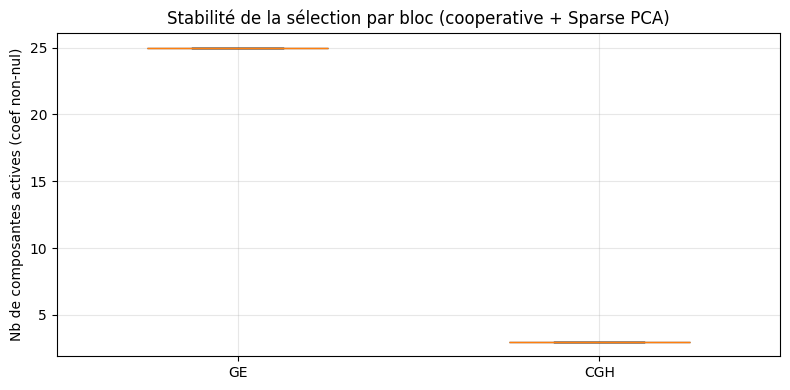

In [12]:
# Refit cooperative + Sparse PCA pipeline sur chaque fold de OUTER_CV
# en utilisant les meilleurs HP trouvés (on utilise le pipeline rapide pour économiser
# le temps de calcul — la stabilité de la sélection ne dépend pas du max_iter de SparsePCA)
best_params = coop_spca_search.best_params_
print(f"Best params (cooperative + Sparse PCA): {best_params}")

active_ge_per_fold  = []
active_cgh_per_fold = []
n_folds = 0

for tr_idx, _ in OUTER_CV.split(X_concat_train, y_train):
    X_tr_fold = X_concat_train.iloc[tr_idx]
    y_tr_fold = y_train.iloc[tr_idx]
    pipe = clone(coop_spca_pipeline_fast).set_params(**best_params)
    pipe.fit(X_tr_fold, y_tr_fold)
    clf = pipe.named_steps["clf"]
    n_active_ge  = int((np.abs(clf.theta_ge_)  > 1e-6).any(axis=1).sum())
    n_active_cgh = int((np.abs(clf.theta_cgh_) > 1e-6).any(axis=1).sum())
    active_ge_per_fold.append(n_active_ge)
    active_cgh_per_fold.append(n_active_cgh)
    n_folds += 1

active_ge_per_fold  = np.array(active_ge_per_fold)
active_cgh_per_fold = np.array(active_cgh_per_fold)

print(f"\nSur {n_folds} folds :")
print(f"  Composantes GE  actives : moyenne {active_ge_per_fold.mean():.1f} / {best_n_ge}    (range {active_ge_per_fold.min()}-{active_ge_per_fold.max()})")
print(f"  Composantes CGH actives : moyenne {active_cgh_per_fold.mean():.1f} / {best_n_cgh}    (range {active_cgh_per_fold.min()}-{active_cgh_per_fold.max()})")

fig, ax = plt.subplots(figsize=(8, 4))
positions = [1, 2]
ax.boxplot([active_ge_per_fold, active_cgh_per_fold], positions=positions, widths=0.5,
           patch_artist=True, labels=['GE', 'CGH'],
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_ylabel('Nb de composantes actives (coef non-nul)')
ax.set_title('Stabilité de la sélection par bloc (cooperative + Sparse PCA)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Coefficients du modèle final

On regarde, sur le modèle refit sur tout le train, lesquelles des composantes Sparse PCA sont actives par classe.


Coefficients GE par classe :


,cort,dipg,midl
GE__SPC1,0.013,0.419,-0.598
GE__SPC2,-0.147,0.301,-0.182
GE__SPC3,0.522,-0.008,-0.543
GE__SPC4,0.127,0.422,-0.707
GE__SPC5,0.140,0.108,-0.267
GE__SPC6,-0.260,-0.328,0.712
GE__SPC7,-0.172,-0.496,0.800
GE__SPC8,0.114,-0.177,0.083
GE__SPC9,-0.144,-0.346,0.604
GE__SPC10,-0.045,0.410,-0.384



Coefficients CGH par classe :


,cort,dipg,midl
CGH__SPC1,-0.352,-0.580,1.118
CGH__SPC2,-0.047,0.022,-0.011
CGH__SPC3,0.001,0.059,-0.081


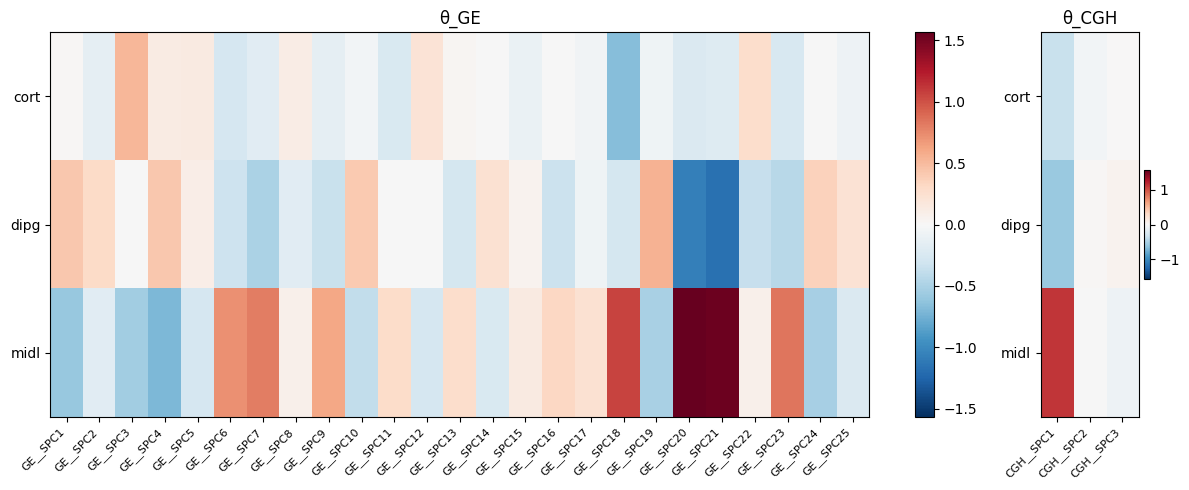

In [13]:
# On utilise le pipeline final (refit qualité-max) pour les coefficients à interpréter
best_pipe = coop_spca_pipeline_final
clf_final = best_pipe.named_steps["clf"]

theta_ge_df = pd.DataFrame(
    clf_final.theta_ge_,
    index=[f"GE__SPC{i+1}"  for i in range(clf_final.theta_ge_.shape[0])],
    columns=clf_final.classes_,
)
theta_cgh_df = pd.DataFrame(
    clf_final.theta_cgh_,
    index=[f"CGH__SPC{i+1}" for i in range(clf_final.theta_cgh_.shape[0])],
    columns=clf_final.classes_,
)

print("Coefficients GE par classe :")
display(theta_ge_df.round(3))
print("\nCoefficients CGH par classe :")
display(theta_cgh_df.round(3))

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          gridspec_kw={'width_ratios': [clf_final.theta_ge_.shape[0], clf_final.theta_cgh_.shape[0]]})
import matplotlib.cm as cm
vmax = max(np.abs(theta_ge_df.values).max(), np.abs(theta_cgh_df.values).max())
for ax, df, title in [
    (axes[0], theta_ge_df,  "θ_GE"),
    (axes[1], theta_cgh_df, "θ_CGH"),
]:
    im = ax.imshow(df.T.values, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(df.index)))
    ax.set_xticklabels(df.index, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(df.columns)))
    ax.set_yticklabels(df.columns)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.05)
plt.tight_layout(); plt.show()


## 10. Conclusion

### Ce que ce notebook démontre

1. **Cooperative Learning fonctionne en multinomial** : l'extension FISTA du papier original (régression) à la cross-entropy converge proprement.
2. **Le sweep `ρ` éclaire la structure du problème** : si l'optimum est à `ρ ≈ 0`, le problème est essentiellement *early fusion* ; si l'optimum est élevé, les blocs sont mieux traités séparément avec une contrainte de cohérence.
3. **Sparse PCA per-block améliore l'interprétabilité** sans dégrader (souvent) la performance — chaque composante est une signature biologique sparse identifiable.
4. **L'analyse de stabilité par bloc** indique si CGH apporte de l'information conditionnellement à GE, ou si cooperative learning collapse vers GE seul.

### Limitations

- **Solveur custom** : pas autant testé que sklearn ou glmnet. Les résultats sont à comparer à `multiview` en R pour vérification.
- **Pas de matrice augmentée** : pour la régression, le papier propose un trick de matrice augmentée qui rend le problème équivalent à un Lasso standard. En multinomial avec cross-entropy, ce trick ne s'applique pas → on paie un FISTA custom.
- **Sample size** : avec n=39, la variance des estimations reste large (CI bootstrap [≈0.5, 1.0] sur le test set). Toute conclusion finale doit être nuancée par cette taille d'échantillon.

### Pistes pour aller plus loin

- **DIABLO** (R `mixOmics`) : version sparse PLS-DA multi-blocs supervisée, à comparer en parallèle.
- **MOFA+** : exploration *non-supervisée* de la structure GE / CGH partagée vs spécifique.
- **Cohorte externe** (OpenPBTA, CBTTC) : seule une validation externe permet de trancher.
- **Cooperative non-linéaire** : extensions kernel ou tree-based existent dans la littérature post-2022.
